# Extension with Stylistic Diversity (D_style)

- Based on a compact stylometric feature vector (11 features)
- Captures *how* a text sounds (tone, register, rhythm) rather than *what* it says (D_sem), *which words* are used (D_lex), *how sentences are built* grammatically (D_syn)

**Features:**
1. Function-word frequency distribution (cosine distance over the NLTK English stopword list)
2. Mean sentence length (alphabetic words per sentence)
3. Sentence length variance (rhythm / burstiness)
4. Flesch Reading Ease
5. Comma density (commas per sentence)
6. Adjective + adverb-to-content-word ratio (via spaCy POS tags)
7. Mean word length in syllables
8. Quotation-mark density (every quotation mark (opening *and* closing) per sentence)
9. Punctuation expressivity (?, !, ellipses per sentence)
10. Mean paragraph length (alphabetic words per paragraph)
11. Sentence-initial pronoun ratio

**Metric formula:**
$$D_{\text{style}} = \frac{1}{\binom{n}{2}} \sum_{i < j} \| \mathbf{z}_i - \mathbf{z}_j \|_2$$
where $\mathbf{z}_i$ is the stylistic feature vector of text $i$, z-standardized with a global mean / SD computed once over every valid text in the whole comparison set (not per prompt × source group).

**Data**
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph

In [25]:
# Load libraries
import json
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
from scipy.spatial.distance import cosine
# kruskal, mannwhitneyu removed (significance testing dropped)
import spacy
import nltk
from nltk.corpus import stopwords  # NLTK is only used for the function-word (stopword) list
import textstat
import warnings
warnings.filterwarnings('ignore')


In [26]:
# Download NLTK resources (stopword list only -- tokenization is spaCy)
nltk.download('stopwords', quiet=True)

# Load spaCy model (sentence segmentation + word tokenization + POS)
nlp = spacy.load('en_core_web_sm')

# Print-oriented plotting defaults
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1081)>


In [27]:
# Configuration
DOMAIN = 'storytelling_n200'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

MIN_SENTENCES = 3           # minimum sentences required to include a text
SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200

In [ ]:
FIG_DIR = Path(f'../../figures/stylistic_diversity/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/02_stylistic_diversity/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Function-word set: NLTK's English stopword list (Bird, Klein & Loper, 2009)
# Restricted to standalone alphabetic entries -> this also drops contraction fragments
_CONTRACTION_FRAGMENTS = {
    'ain', 'aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven',
    'isn', 'mightn', 'mustn', 'needn', 'shan', 'shouldn', 'wasn', 'weren',
    'won', 'wouldn', 'd', 'll', 'm', 'ma', 'o', 're', 's', 't', 've', 'y',
}


FUNCTION_WORDS = sorted(
    w for w in stopwords.words('english')
    if w.isalpha() and w not in _CONTRACTION_FRAGMENTS
)

# Quotation marks counted for the quotation-mark-density feature: straight and curly doubles, German low-9 and guillemets, opening and closing
QUOTATION_MARKS = ('"', '“', '”', '„', '«', '»')

# A "word" for the length features = a maximal run of Unicode letters (no digits, no underscore, no punctuation)
_WORD_RE = re.compile(r"[^\W\d_]+", re.UNICODE)

def alpha_words(text: str) -> list:
    """List of alphabetic word tokens in ``text`` (letters only)."""
    return _WORD_RE.findall(text)

print("Configuration:")
print(f"  Domain:                 {DOMAIN}")
print(f"  Function word set size: {len(FUNCTION_WORDS)}")
print(f"  Min sentences:          {MIN_SENTENCES}")

## Load Dataset

In [29]:
# Repo root importable regardless of the kernel's working directory
import sys

def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from common import data_prep
from common import MODEL_LABELS, MODEL_COLORS

DATA_DIR = data_prep.GENERATIONS_DIR / DOMAIN
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Canonical load: quality filter (model: truncation / language drift; human: language drift + exact-duplicate) + storytelling human 5-cap
_df = data_prep.load_texts(DOMAIN, n_prompts=N_PROMPTS)
df = _df[['prompt_id', 'source', 'story_id', 'text']].reset_index(drop=True)

SOURCE_COLORS = {s: MODEL_COLORS[MODEL_LABELS[s]] for s in SOURCES}

n_dropped = {s: 5 * N_PROMPTS - int((df.source == s).sum()) for s in SOURCES if s != 'human'}
print(f"Loaded: {len(df)} texts ({df['prompt_id'].nunique()} prompts x {len(SOURCES)} sources)")
print(f"Dropped (quality filter): {n_dropped}")
df.head()

DOMAIN = 'storytelling_n200'  (/Users/thwin/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/storytelling_n200)
Loaded: 4972 texts (200 prompts x 5 sources)
Dropped (quality filter): {'llama': 4, 'mistral': 15, 'qwen': 8, 'gemma': 0}


,prompt_id,source,story_id,text
0,0,human,0,"Here is my first post, I have always wanted to..."
1,0,human,1,`` The purpose of life is war. It has always b...
2,0,human,2,"“ Dr. Garyson, you have five seconds to cut to..."
3,0,human,3,"Just found this sub, I've never written before..."
4,0,human,5,`` What the fuck is going on!'' I scream from ...


In [30]:
print(f"\nSources: {df['source'].unique()}")
print(f"Prompts: {df['prompt_id'].nunique()}")


Sources: <ArrowStringArray>
['human', 'gemma', 'llama', 'mistral', 'qwen']
Length: 5, dtype: str
Prompts: 200


## Feature Extraction

- Each feature is computed per text
- Tokenization is spaCy: sentence segmentation via `doc.sents`, word tokens via `doc`
- NLTK is only the 124-word function-word (stopword) list
- Feature 1 is a 124-dim distribution handled separately via cosine distance (not z-standardized like the others, since it's already a normalized distribution). It is `None` for a text that contains none of the 124 function words (such a text is dropped from the function-word component)
- Features 2–11 are scalars (10 features). Sentence and paragraph length count alphabetic words (`alpha_words`, a regex over Unicode letter runs), not tokenizer tokens

In [31]:
def count_syllables(word: str) -> int:
    """Simple heuristic syllable counter (vowel-group based)"""

    # Convert to lowercase and define vowels
    word = word.lower()
    vowels = 'aeiouy'

    count = 0
    prev_was_vowel = False
    
    # Count vowel groups
    for ch in word:
        is_vowel = ch in vowels

        # Count a new syllable if we encounter a vowel that is not part of a previous vowel group
        if is_vowel and not prev_was_vowel:
            count += 1
        prev_was_vowel = is_vowel
    
    # Adjust for silent 'e' at the end of words
    if word.endswith('e') and count > 1:
        count -= 1
    
    return max(count, 1)


def extract_style_features(text: str, min_sentences: int = MIN_SENTENCES):
    """
    Extract 11-feature stylistic vector for a single text.
    Returns a dict or None if the text is too short to analyze.
    The 'fw_dist' entry is None when the text contains none of the function
    words (the scalar features are still valid).

    Tokenization runs through spaCy: sentence segmentation via ``doc.sents`` 
    and word tokens via ``doc`` (NLTK is only the function-word list)
    """
    # Sentence + word tokenization via spaCy
    doc = nlp(text)
    sentences = [s for s in doc.sents if len(s.text.strip()) > 0]

    # Drop texts with too few sentences (e.g., empty or single-sentence texts)
    if len(sentences) < min_sentences:
        return None

    # Word tokens, filtered to alphabetic tokens
    words_alpha = [t.text.lower() for t in doc if t.text.isalpha()]

    # Drop texts with no alphabetic words (e.g., only punctuation or numbers)
    if len(words_alpha) == 0:
        return None

    # Feature 1: function-word frequency distribution. A text with no function
    # word at all gets fw_dist = None and is dropped from the FW component downstream
    fw_counts = np.array([words_alpha.count(fw) for fw in FUNCTION_WORDS], dtype=float)
    fw_total = fw_counts.sum()
    fw_dist = fw_counts / fw_total if fw_total > 0 else None

    # Feature 2 & 3: sentence length mean & variance (alphabetic words per sentence)
    sent_lengths = [len(alpha_words(s.text)) for s in sentences]
    sent_len_mean = np.mean(sent_lengths)
    sent_len_var = np.var(sent_lengths)

    # Feature 4: Flesch Reading Ease (via textstat)
    flesch = textstat.flesch_reading_ease(text)

    # Feature 5: comma density (commas per sentence)
    comma_count = text.count(',')
    comma_density = comma_count / len(sentences)

    # Feature 6: (adjective + adverb) to content-word ratio via spaCy
    # Define content words as nouns, verbs, adjectives, adverbs and proper nouns
    content_pos = {'NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN'}
    adj_adv_pos = {'ADJ', 'ADV'}
    content_tokens = [t for t in doc if t.pos_ in content_pos]
    adj_adv_tokens = [t for t in doc if t.pos_ in adj_adv_pos]
    adj_adv_ratio = len(adj_adv_tokens) / (len(content_tokens) + 1e-9)

    # Feature 7: mean word length in syllables
    syllable_counts = [count_syllables(w) for w in words_alpha]
    mean_syllables = np.mean(syllable_counts)

    # Feature 8: quotation-mark density
    # Count every quotation mark, opening and closing, as a proxy for dialogue
    quote_marks = sum(text.count(q) for q in QUOTATION_MARKS)
    dialogue_ratio = quote_marks / (len(sentences) + 1e-9)

    # Feature 9: punctuation expressivity (?, !, ellipses per sentence)
    expressive_punct = text.count('?') + text.count('!') + text.count('…') + text.count('...')
    punct_expressivity = expressive_punct / (len(sentences) + 1e-9)

    # Feature 10: mean paragraph length (alphabetic words per paragraph)
    paragraphs = [p.strip() for p in text.split('\n\n') if len(p.strip()) > 0]
    if len(paragraphs) == 0:
        paragraphs = [text]
    mean_para_length = np.mean([len(alpha_words(p)) for p in paragraphs])

    # Feature 11: sentence-initial pronoun ratio, checked on the first
    # *alphabetic* token of each sentence (skips leading quotes, dashes, other
    # punctuation)
    pron_starts = 0
    for s in sentences:
        first_alpha = next((tok for tok in s if tok.is_alpha), None)
        if first_alpha is not None and first_alpha.pos_ == 'PRON':
            pron_starts += 1
    sent_start_pron_ratio = pron_starts / (len(sentences) + 1e-9)

    return {
        'fw_dist': fw_dist,
        'sent_len_mean': sent_len_mean,
        'sent_len_var': sent_len_var,
        'flesch_reading_ease': flesch,
        'comma_density': comma_density,
        'adj_adv_ratio': adj_adv_ratio,
        'mean_syllables': mean_syllables,
        'dialogue_ratio': dialogue_ratio,
        'punct_expressivity': punct_expressivity,
        'mean_para_length': mean_para_length,
        'sent_start_pron_ratio': sent_start_pron_ratio,
    }


features = df['text'].apply(extract_style_features)
df['features'] = features

n_valid = df['features'].notna().sum()
n_invalid = df['features'].isna().sum()
print(f"Valid feature extractions: {n_valid}")
print(f"Skipped (too short):       {n_invalid}")

df_valid = df.dropna(subset=['features']).copy()
n_no_fw = df_valid['features'].apply(lambda f: f['fw_dist'] is None).sum()
print(f"Valid texts with no function word (fw_dist=None, excluded from FW component): {n_no_fw}")

Valid feature extractions: 4963
Skipped (too short):       9
Valid texts with no function word (fw_dist=None, excluded from FW component): 3


In [47]:
# Unpack scalar features into separate columns
scalar_feature_names = [
    'sent_len_mean', 'sent_len_var', 'flesch_reading_ease',
    'comma_density', 'adj_adv_ratio', 'mean_syllables',
    'dialogue_ratio', 'punct_expressivity', 'mean_para_length', 'sent_start_pron_ratio',
]

# Human-readable labels for plot titles
FEATURE_LABELS = {
    'sent_len_mean': 'Mean Sentence Length',
    'sent_len_var': 'Sentence Length Variance',
    'flesch_reading_ease': 'Flesch Reading Ease',
    'comma_density': 'Comma Density',
    'adj_adv_ratio': 'Adjective + Adverb Ratio',
    'mean_syllables': 'Mean Word Length (Syllables)',
    'dialogue_ratio': 'Quotation-Mark Density',
    'punct_expressivity': 'Punctuation Expressivity',
    'mean_para_length': 'Mean Paragraph Length',
    'sent_start_pron_ratio': 'Sentence-Initial Pronoun Ratio',
}

for fname in scalar_feature_names:
    df_valid[fname] = df_valid['features'].apply(lambda f: f[fname])

df_valid['fw_dist'] = df_valid['features'].apply(lambda f: f['fw_dist'])

feature_descriptives = df_valid[['source'] + scalar_feature_names].groupby('source').describe().round(3)
feature_descriptives.to_csv(TABLE_DIR / 'feature_descriptives_by_source.csv')
feature_descriptives


sent_len_mean                                                        \
                count    mean    std    min     25%     50%     75%     max   
source                                                                        
gemma          1000.0  12.363  2.913  2.045  10.645  12.055  13.564  37.692   
human           997.0  13.270  4.918  5.000  10.208  12.390  15.333  70.333   
llama           992.0  15.089  4.043  2.091  12.550  14.515  16.952  53.095   
mistral         985.0  16.614  3.714  1.044  14.278  16.235  18.556  37.714   
qwen            989.0  14.673  3.670  1.000  12.243  14.289  16.750  47.000   

        sent_len_var          ... mean_para_length          \
               count    mean  ...              75%     max   
source                        ...                            
gemma         1000.0  43.437  ...           41.545   490.0   
human          997.0  77.746  ...          700.000  1853.0   
llama          992.0  62.173  ...           58.878  1025.0   
mistral        985.0  43.336  ...           56.273    93.6   
qwen           989.0  43.797  ...           60.750   282.0   

        sent_start_pron_ratio                                                 
                        count   mean    std  min    25%    50%    75%    max  
source                                                                        
gemma                  1000.0  0.445  0.126  0.0  0.370  0.450  0.526  1.000  
human                   997.0  0.418  0.156  0.0  0.316  0.419  0.529  1.000  
llama                   992.0  0.434  0.153  0.0  0.333  0.446  0.549  0.867  
mistral                 985.0  0.378  0.154  0.0  0.273  0.371  0.484  0.851  
qwen                    989.0  0.386  0.135  0.0  0.302  0.386  0.471  0.815  

[5 rows x 80 columns]

In [48]:
export_cols = [
    "prompt_id",
    "source",
    "sent_len_mean",
    "sent_len_var",
    "adj_adv_ratio",
    "mean_syllables",
    "dialogue_ratio",
    "punct_expressivity",
    "sent_start_pron_ratio",
]

df_valid[export_cols].to_csv(
    TABLE_DIR / "style_features_per_text.csv",
    index=False
)

## Feature Redundancy Analysis

In [ ]:
# Compute Spearman correlation matrix for scalar features
corr_matrix = df_valid[scalar_feature_names].corr(method='spearman')
corr_matrix.to_csv(TABLE_DIR / 'feature_correlation_matrix.csv')

fig, ax = plt.subplots(figsize=(6.3, 5.5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title("Spearman Correlation between Scalar Features", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [50]:
# Flag high correlations (|r| > 0.6)
high_corr = []
for i in range(len(scalar_feature_names)):
    for j in range(i + 1, len(scalar_feature_names)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            high_corr.append((scalar_feature_names[i], scalar_feature_names[j], r))

print("\nHighly correlated feature pairs (|r| > 0.6):")
if high_corr:
    for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {f1:30s} <-> {f2:30s}  r = {r:+.3f}")
else:
    print("  None found — no feature pairs exceed |r| = 0.6")

pd.DataFrame(high_corr, columns=['feature_1', 'feature_2', 'spearman_r']).to_csv(
    TABLE_DIR / 'high_correlation_pairs.csv', index=False
)


Highly correlated feature pairs (|r| > 0.6):
  flesch_reading_ease            <-> mean_syllables                  r = -0.878
  sent_len_mean                  <-> comma_density                   r = +0.694
  dialogue_ratio                 <-> mean_para_length                r = -0.634


In [51]:
# Final scalar feature set for D_style.
#
# Redundancy screening was performed once during metric construction on the
# WritingPrompts data (`storytelling_n200`). The resulting feature set is kept
# fixed across both tasks so that D_style has the same definition for
# WritingPrompts and PAR3.
#
# The correlation analysis above is therefore task-specific diagnostic
# information only; it does not trigger a new feature selection for each task.
#
# During the WritingPrompts redundancy screening, one feature was removed from
# each strongly correlated pair to avoid double-weighting closely related
# stylistic properties:
#   flesch_reading_ease  -> represented by mean_syllables
#   comma_density        -> represented by sent_len_mean
#   mean_para_length     -> represented by dialogue_ratio

REDUNDANT_FEATURES = [
    'flesch_reading_ease',
    'comma_density',
    'mean_para_length'
]

scalar_features_reduced = [
    f for f in scalar_feature_names
    if f not in REDUNDANT_FEATURES
]

print(f"All scalar features ({len(scalar_feature_names)}): {scalar_feature_names}")
print(f"\nRemoved as redundant: {REDUNDANT_FEATURES}")
print(f"\nFeatures used for D_style computation ({len(scalar_features_reduced)}):")
for f in scalar_features_reduced:
    print(f"  - {f}")

All scalar features (10): ['sent_len_mean', 'sent_len_var', 'flesch_reading_ease', 'comma_density', 'adj_adv_ratio', 'mean_syllables', 'dialogue_ratio', 'punct_expressivity', 'mean_para_length', 'sent_start_pron_ratio']

Removed as redundant: ['flesch_reading_ease', 'comma_density', 'mean_para_length']

Features used for D_style computation (7):
  - sent_len_mean
  - sent_len_var
  - adj_adv_ratio
  - mean_syllables
  - dialogue_ratio
  - punct_expressivity
  - sent_start_pron_ratio


## Compute D_style per Prompt × Source

1. The 7 scalar features are z-standardized with a global mean / SD per feature, computed once over all valid texts in the comparison set (every source, every prompt), not per prompt × source group
2. Pairwise Euclidean distances are then taken within each prompt × source group -> the scalar component measures a group's spread on a fixed shared scale
3. The function-word distribution is combined via mean pairwise cosine distance, over only those texts that contain at least one function word (texts with `fw_dist=None` are excluded)
4. A group with fewer than 2 valid texts -> scalar component = NA
5. Fewer than 2 texts with a function-word distribution -> function-word component = NA

In [52]:
def compute_d_style(group: pd.DataFrame, scalar_features: list, mu: np.ndarray, sigma: np.ndarray):
    """
    Raw stylistic distance components for one (prompt_id, source) group.
    Returns (scalar_component, fw_component), each is np.nan when undefined:
      - scalar_component: mean pairwise Euclidean distance over the scalar
        features, z-standardized with the gloabl mu / sigma (computed once over
        all valid texts) -> np.nan if the group has fewer than 2 texts
      - fw_component: mean pairwise cosine distance over the function-word
        distributions, restricted to texts that actually contain a function word
        -> np.nan if fewer than 2 such texts remain

    Normalization and combination into D_style happen globally after all groups
    are computed, so both components can be scaled to the same range.
    """
    n = len(group)

    # 1. Scalar component -- global z-standardization, then within-group pairwise distance
    if n < 2:
        scalar_component = np.nan
    else:
        scalar_matrix = group[scalar_features].values.astype(float)
        sigma_safe = np.where(sigma == 0, 1.0, sigma)
        z = (scalar_matrix - mu) / sigma_safe
        pairs = list(combinations(range(n), 2))
        scalar_component = np.mean([np.linalg.norm(z[i] - z[j]) for i, j in pairs])

    # 2. Function-word component -- only texts with a function-word distribution
    fw_vectors = [v for v in group['fw_dist'].values if v is not None]
    if len(fw_vectors) < 2:
        fw_component = np.nan
    else:
        fw_arr = np.stack(fw_vectors)
        fw_pairs = list(combinations(range(len(fw_vectors)), 2))
        fw_component = np.mean([cosine(fw_arr[i], fw_arr[j]) for i, j in fw_pairs])

    return scalar_component, fw_component


# Global z-standardization params: one mean / SD per scalar feature over all
# valid texts in the comparison set (every source, every prompt)
global_mu = df_valid[scalar_features_reduced].values.astype(float).mean(axis=0)
global_sigma = df_valid[scalar_features_reduced].values.astype(float).std(axis=0)

# Compute raw components for each (prompt_id, source) pair (NA rows are kept, not dropped)
results = []
for (prompt_id, source), group in df_valid.groupby(['prompt_id', 'source']):
    scalar_part, fw_part = compute_d_style(group, scalar_features_reduced, global_mu, global_sigma)
    results.append({
        'prompt_id': prompt_id,
        'source': source,
        'n_texts': len(group),
        'n_texts_fw': int(sum(v is not None for v in group['fw_dist'].values)),
        'D_style_scalar_component': scalar_part,
        'D_style_funcword_component': fw_part,
    })

df_style = pd.DataFrame(results)

n_scalar_na = df_style['D_style_scalar_component'].isna().sum()
n_fw_na = df_style['D_style_funcword_component'].isna().sum()
print(f"Computed D_style components for {len(df_style)} (prompt, source) pairs")
print(f"  scalar component NA (< 2 valid texts):                  {n_scalar_na}")
print(f"  function-word component NA (< 2 texts with a fw_dist):  {n_fw_na}")
print(f"\nRaw scalar component range: [{df_style['D_style_scalar_component'].min():.4f}, {df_style['D_style_scalar_component'].max():.4f}]")
print(f"Raw FW component range: [{df_style['D_style_funcword_component'].min():.4f}, {df_style['D_style_funcword_component'].max():.4f}]")


Computed D_style components for 1000 (prompt, source) pairs
  scalar component NA (< 2 valid texts):                  1
  function-word component NA (< 2 texts with a fw_dist):  2

Raw scalar component range: [0.8653, 26.3181]
Raw FW component range: [0.0273, 0.9771]


## Outlier Check

Min-max normalization problematic if there are extreme observations, can compress the rest of distribution into a narrow band

D_style_scalar_component: bounds=[0.4325, 3.7399] (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  -> 56 outlier(s) (5.6% of 1000 observations)
D_style_funcword_component: bounds=[-0.0696, 0.3327] (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
  -> 42 outlier(s) (4.2% of 1000 observations)

Scalar component outliers:


,prompt_id,source,D_style_scalar_component
551,110,human,3.760019
236,47,human,3.761961
94,18,qwen,3.762366
970,194,gemma,3.768633
196,39,human,3.772227
36,7,human,3.845699
366,73,human,3.868487
786,157,human,3.876182
431,86,human,3.883030
331,66,human,3.889998



Function-word component outliers:


,prompt_id,source,D_style_funcword_component
761,152,human,0.334063
71,14,human,0.338832
681,136,human,0.340285
421,84,human,0.340600
366,73,human,0.343859
136,27,human,0.346406
986,197,human,0.350108
886,177,human,0.351532
386,77,human,0.352886
451,90,human,0.353430


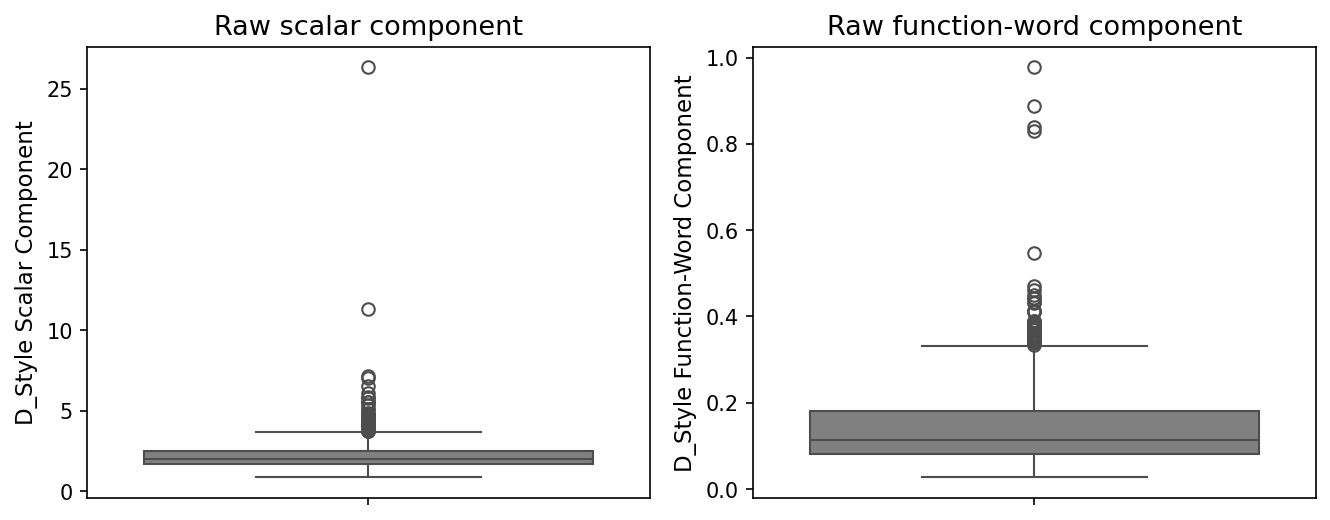

In [53]:
# Compute IQR bounds for outlier detection
def iqr_bounds(series: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Report outliers for a given column in the D_style DataFrame
def report_outliers(df: pd.DataFrame, col: str, k: float = 1.5) -> pd.DataFrame:

    # Compute IQR bounds and identify outliers
    lower, upper = iqr_bounds(df[col], k)
    outliers = df[(df[col] < lower) | (df[col] > upper)]


    print(f"{col}: bounds=[{lower:.4f}, {upper:.4f}] (Q1 - {k}*IQR, Q3 + {k}*IQR)")
    print(f"  -> {len(outliers)} outlier(s) ({len(outliers) / len(df):.1%} of {len(df)} observations)")
    return outliers.sort_values(col)[['prompt_id', 'source', col]]

scalar_outliers = report_outliers(df_style, 'D_style_scalar_component')
fw_outliers = report_outliers(df_style, 'D_style_funcword_component')

print("\nScalar component outliers:")
display(scalar_outliers)
print("\nFunction-word component outliers:")
display(fw_outliers)

# Save outlier tables for reference
scalar_outliers.to_csv(TABLE_DIR / 'outliers_scalar_component.csv', index=False)
fw_outliers.to_csv(TABLE_DIR / 'outliers_funcword_component.csv', index=False)


# Boxplots of the raw D_style components, before outlier removal
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))

sns.boxplot(y=df_style['D_style_scalar_component'], ax=axes[0], color='gray')
axes[0].set_title('Raw scalar component')
axes[0].set_ylabel('D_Style Scalar Component')

sns.boxplot(y=df_style['D_style_funcword_component'], ax=axes[1], color='gray')
axes[1].set_title('Raw function-word component')
axes[1].set_ylabel('D_Style Function-Word Component')

plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_boxplots_outliers_before.png', dpi=300, bbox_inches='tight')
plt.show()


-> Scalar-Component: all on the lower bound and mostly AI-stories  
-> Function-Word-Component: all on the upper bound and mostly human stories

In [54]:
# Winsorize both components at (Q1 - 1.5*IQR, Q3 + 1.5*IQR), then min-max normalize to [0,1].
# NaN components (groups with < 2 valid texts, or < 2 texts with a function-word
# distribution) stay NaN

def winsorized_minmax(series: pd.Series, k: float = 1.5) -> pd.Series:
    
    # Get IQR bounds (over the defined values only)
    lower, upper = iqr_bounds(series, k)
    # Clip values outside the bounds (NaN stays NaN)
    clipped = series.clip(lower, upper)
    # Min-max normalize to [0,1]
    return (clipped - clipped.min()) / (clipped.max() - clipped.min())

df_style['scalar_norm'] = winsorized_minmax(df_style['D_style_scalar_component'])
df_style['fw_norm']     = winsorized_minmax(df_style['D_style_funcword_component'])
df_style['D_style']     = 0.5 * df_style['scalar_norm'] + 0.5 * df_style['fw_norm']

# Groups where D_style is undefined (either component NA)
n_d_style_na = df_style['D_style'].isna().sum()
print(f"D_style = NA for {n_d_style_na} of {len(df_style)} (prompt, source) pairs")

# Subset with a defined D_style, used for the statistical testing further down
df_style_valid = df_style.dropna(subset=['D_style']).copy()

print(f"Normalized scalar range: [{df_style['scalar_norm'].min():.4f}, {df_style['scalar_norm'].max():.4f}]")
print(f"Normalized FW range: [{df_style['fw_norm'].min():.4f}, {df_style['fw_norm'].max():.4f}]")

d_style_descriptives = df_style.groupby('source')['D_style'].describe().round(4)

d_style_descriptives.to_csv(TABLE_DIR / 'd_style_descriptives_by_source.csv')
d_style_descriptives


D_style = NA for 2 of 1000 (prompt, source) pairs
Normalized scalar range: [0.0000, 1.0000]
Normalized FW range: [0.0000, 1.0000]


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
gemma,200.0,0.2920,0.1303,0.0607,0.1974,0.2659,0.3695,0.8877
human,200.0,0.7456,0.1711,0.2571,0.6174,0.7681,0.8827,1.0000
llama,199.0,0.3363,0.1298,0.1070,0.2466,0.3165,0.3993,0.8084
mistral,200.0,0.3260,0.1369,0.0860,0.2289,0.3084,0.3852,1.0000
qwen,199.0,0.3448,0.1457,0.0393,0.2543,0.3283,0.4019,0.9639


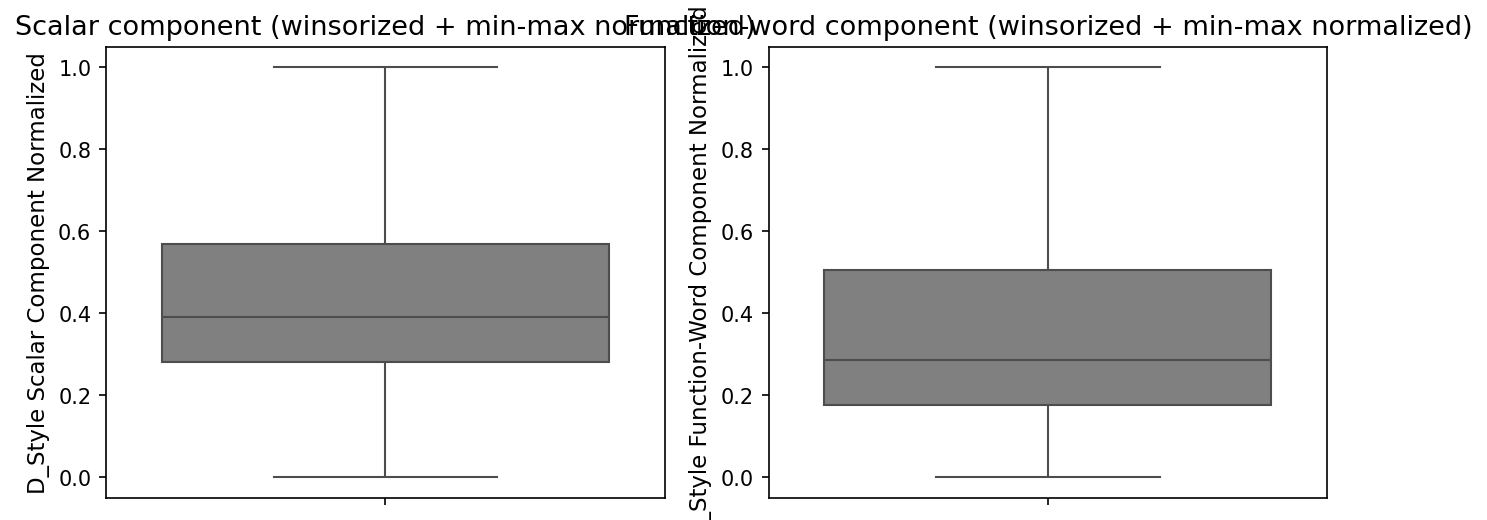

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
sns.boxplot(y=df_style['scalar_norm'], ax=axes[0], color='gray')
axes[0].set_title('Scalar component (winsorized + min-max normalized)')
axes[0].set_ylabel('D_Style Scalar Component Normalized')

sns.boxplot(y=df_style['fw_norm'], ax=axes[1], color='gray')
axes[1].set_title('Function-word component (winsorized + min-max normalized)')
axes[1].set_ylabel('D_Style Function-Word Component Normalized')

plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_boxplots_outliers_after.png', dpi=300, bbox_inches='tight')
plt.show()


## Descriptive Analysis

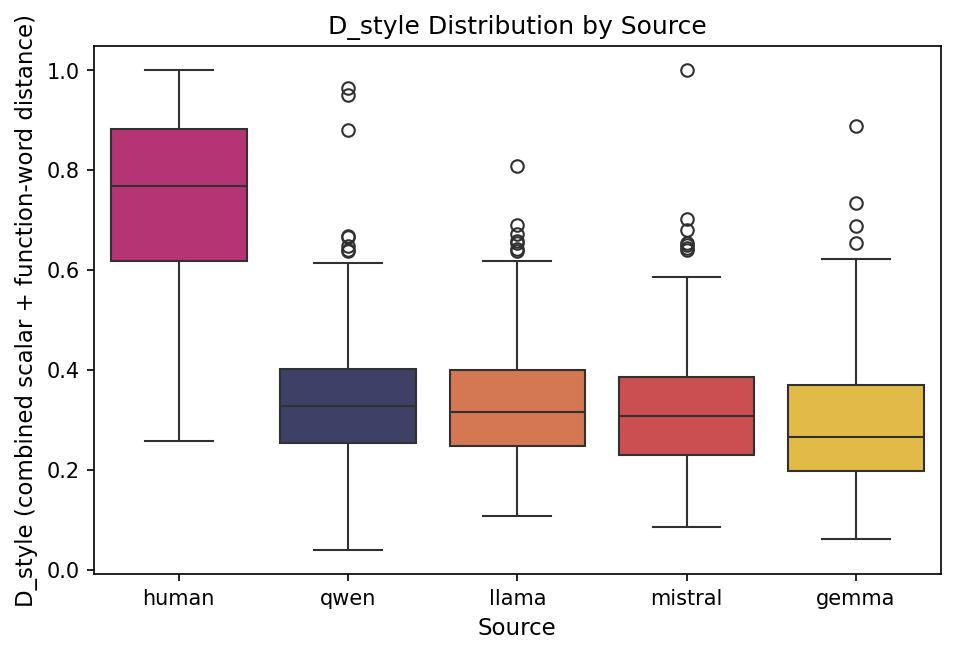

,mean,std
source,,
human,0.7456,0.1711
qwen,0.3448,0.1457
llama,0.3363,0.1298
mistral,0.3260,0.1369
gemma,0.2920,0.1303


In [56]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

source_order = df_style.groupby('source')['D_style'].median().sort_values(ascending=False).index.tolist()
sns.boxplot(data=df_style, x='source', y='D_style', order=source_order,
            palette=[SOURCE_COLORS[s] for s in source_order], ax=ax)
ax.set_title('D_style Distribution by Source', fontsize=12)
ax.set_xlabel('Source')
ax.set_ylabel('D_style (combined scalar + function-word distance)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_boxplots_combined.png', dpi=300, bbox_inches='tight')
plt.show()

d_style_mean_std = df_style.groupby('source')['D_style'].agg(['mean', 'std']).reindex(source_order).round(4)
d_style_mean_std.to_csv(TABLE_DIR / 'd_style_mean_std_by_source.csv')
d_style_mean_std


## Component Breakdown

Compare the function-word component vs. the scalar-feature component to see which drives D_style per source

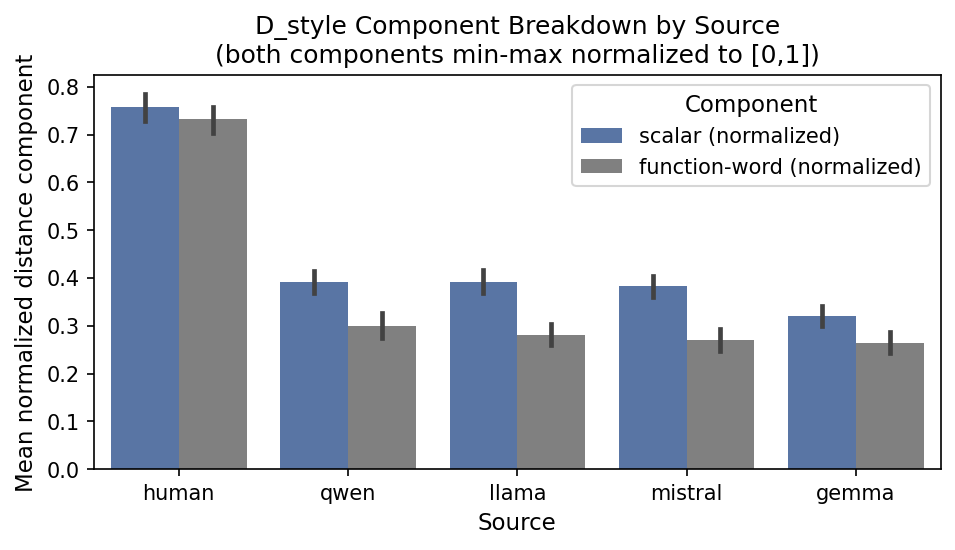

In [57]:
component_df = df_style.melt(
    id_vars=['prompt_id', 'source'],
    value_vars=['scalar_norm', 'fw_norm'],
    var_name='component', value_name='value'
)
component_df['component'] = component_df['component'].map({
    'scalar_norm': 'scalar (normalized)',
    'fw_norm':     'function-word (normalized)'
})

fig, ax = plt.subplots(figsize=(6.5, 3.8))
sns.barplot(data=component_df, x='source', y='value', hue='component',
            order=source_order, ax=ax, palette=['#4C72B0', 'gray'])
ax.set_title('D_style Component Breakdown by Source\n(both components min-max normalized to [0,1])', fontsize=12)
ax.set_xlabel('Source')
ax.set_ylabel('Mean normalized distance component')
ax.legend(title='Component')
plt.tight_layout()
plt.savefig(FIG_DIR / 'd_style_component_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

## Individual Feature Distributions

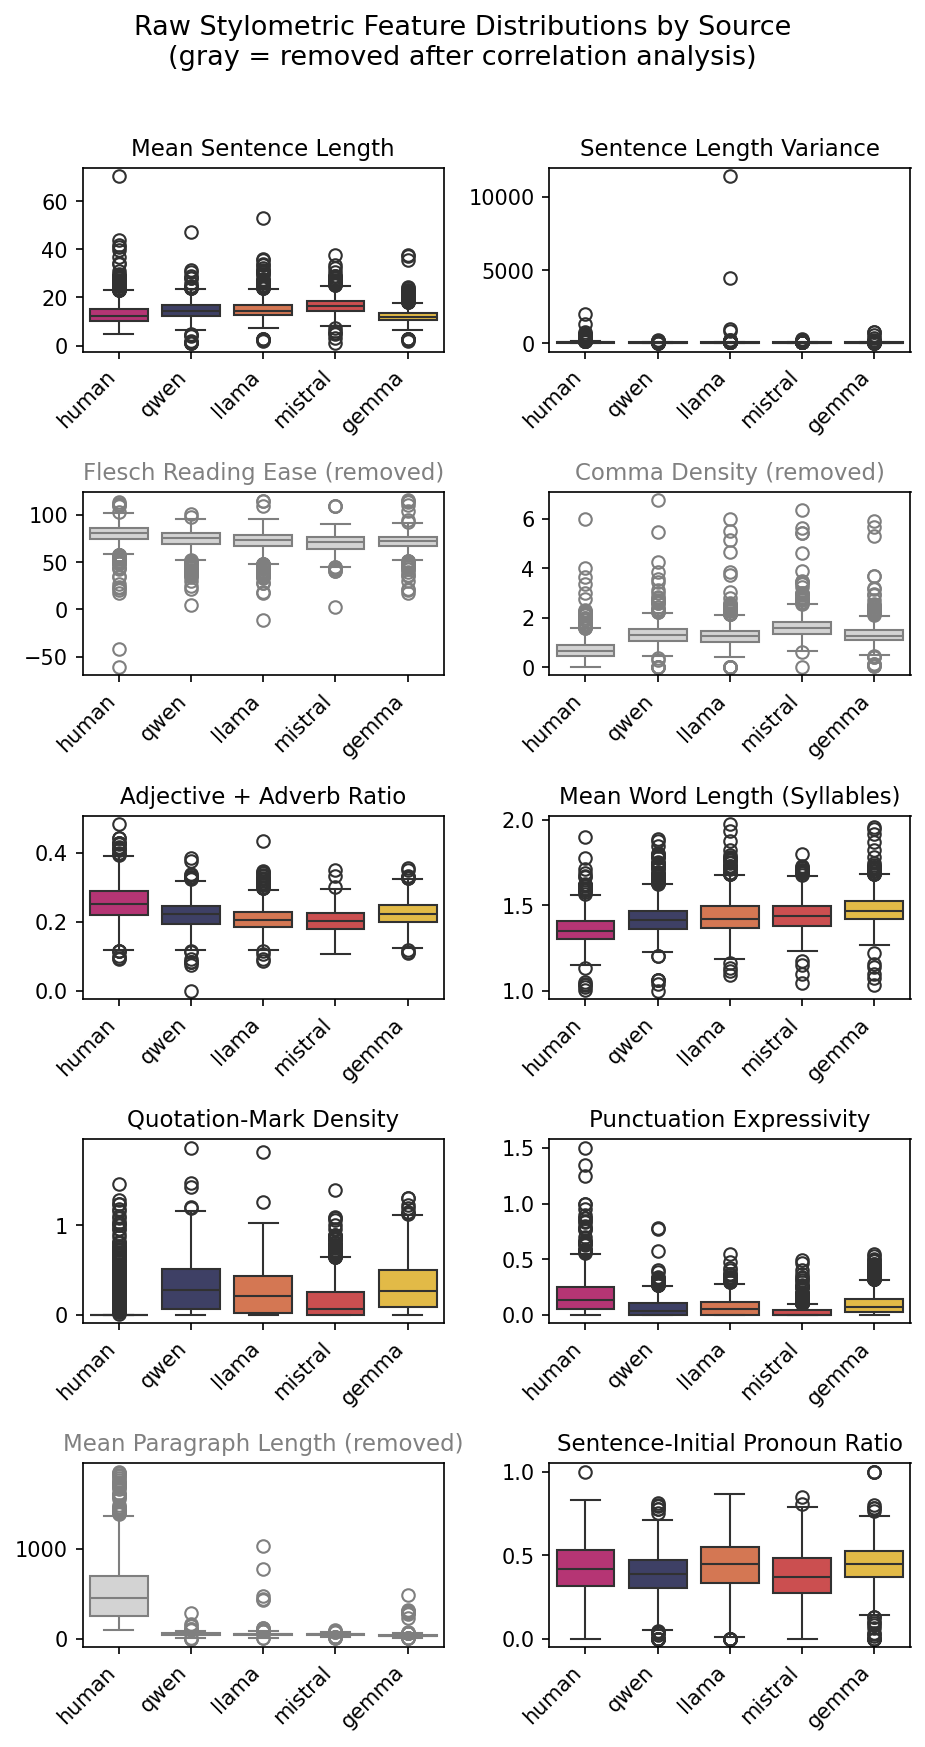

In [58]:
n_features = len(scalar_feature_names)
n_rows, n_cols = 5, 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.15, n_rows * 2.3))
axes = axes.flatten()

for ax, fname in zip(axes, scalar_feature_names):
    is_removed = fname in REDUNDANT_FEATURES
    palette = ['lightgray'] * len(source_order) if is_removed else [SOURCE_COLORS[s] for s in source_order]
    sns.boxplot(data=df_valid, x='source', y=fname, order=source_order, palette=palette, ax=ax)
    label = FEATURE_LABELS[fname]
    title_kwargs = {'color': 'gray'} if is_removed else {}
    ax.set_title(f'{label} (removed)' if is_removed else label, fontsize=11, **title_kwargs)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any unused subplots
for ax in axes[n_features:]:
    ax.set_visible(False)

fig.suptitle('Raw Stylometric Feature Distributions by Source\n(gray = removed after correlation analysis)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_stylometric_features_by_source.png', dpi=300, bbox_inches='tight')
plt.show()


## Weighting Sensitivity Analysis

- No strong theoretical justification for 0.5/0.5 split between the scalar and function-word component
- Treats two stylistic components as equally important by default.
- Recompute D_style under alternative weightings and check whether the Kruskal-Wallis / Mann-Whitney conclusions above stay the same

In [59]:
pairs = list(combinations(SOURCES, 2))

# Scalar-component weight; fw weight = 1 - w
WEIGHTS = [0.3, 0.5, 0.7]

sensitivity_rows = []
mean_by_weight = {}

# Vary the weights of the scalar and function-word components (NA groups excluded)
for w in WEIGHTS:

    # Compute weighted D_style for each (prompt_id, source) pair
    d_style_w = w * df_style_valid['scalar_norm'] + (1 - w) * df_style_valid['fw_norm']

    # Compute mean D_style by source
    means = d_style_w.groupby(df_style_valid['source']).mean().reindex(SOURCES)
    mean_by_weight[w] = means
    ranking = means.sort_values(ascending=False).index.tolist()


    sensitivity_rows.append({
        'scalar_weight': w, 'fw_weight': round(1 - w, 2),
        **{f'mean_{s}': means[s] for s in SOURCES},
        'ranking': ' > '.join(ranking),
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df.to_csv(TABLE_DIR / 'd_style_weight_sensitivity_means.csv', index=False)

print("Mean D_style by source across weightings:")
display(sensitivity_df)

# Check whether the source ranking is stable across weightings
ranking_stable = sensitivity_df['ranking'].nunique() == 1
print(f"\nSource ranking stable across weightings: {ranking_stable}")

# Pairwise mean gap per weighting
gap_rows = []
for w in WEIGHTS:
    for s1, s2 in pairs:
        gap_rows.append({'w': w, 'pair': f'{s1} vs {s2}',
                         'mean_gap': mean_by_weight[w][s1] - mean_by_weight[w][s2]})


gap_df = pd.DataFrame(gap_rows).pivot(index='pair', columns='w', values='mean_gap')
gap_df.columns = [f'w={w}' for w in gap_df.columns]
gap_df.to_csv(TABLE_DIR / 'd_style_weight_sensitivity_gap.csv')

print("\nPairwise mean D_style gap by weighting:")
display(gap_df.round(4))

# Pairs whose gap sign flips across weightings
sign_df = np.sign(gap_df)
sign_df.to_csv(TABLE_DIR / 'd_style_weight_sensitivity_sign.csv')


Mean D_style by source across weightings:


,scalar_weight,fw_weight,mean_human,mean_llama,mean_mistral,mean_qwen,mean_gemma,ranking
0,0.3,0.7,0.740340,0.314387,0.303424,0.326916,0.280699,human > qwen > llama > mistral > gemma
1,0.5,0.5,0.745595,0.336348,0.325956,0.344827,0.291977,human > qwen > llama > mistral > gemma
2,0.7,0.3,0.750850,0.358310,0.348487,0.362739,0.303254,human > qwen > llama > mistral > gemma



Source ranking stable across weightings: True

Pairwise mean D_style gap by weighting:


,w=0.3,w=0.5,w=0.7
pair,,,
human vs gemma,0.4596,0.4536,0.4476
human vs llama,0.4260,0.4092,0.3925
human vs mistral,0.4369,0.4196,0.4024
human vs qwen,0.4134,0.4008,0.3881
llama vs gemma,0.0337,0.0444,0.0551
llama vs mistral,0.0110,0.0104,0.0098
llama vs qwen,-0.0125,-0.0085,-0.0044
mistral vs gemma,0.0227,0.0340,0.0452
mistral vs qwen,-0.0235,-0.0189,-0.0143


## Component Breakdown of Weighting-Sensitive Pairs

In [60]:
def component_mean_gap(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """Descriptive mean gap per source pair for a given D_style component column."""
    means = df.groupby('source')[col].mean().reindex(SOURCES)
    rows = [{'pair': f'{s1} vs {s2}', col: means[s1] - means[s2]} for s1, s2 in pairs]
    return pd.DataFrame(rows).set_index('pair')

scalar_breakdown = component_mean_gap(df_style_valid, 'scalar_norm')
fw_breakdown = component_mean_gap(df_style_valid, 'fw_norm')

breakdown_df = scalar_breakdown.join(fw_breakdown)
breakdown_df.to_csv(TABLE_DIR / 'd_style_component_breakdown_gap.csv')
print("Mean gap per source pair, by D_style component (descriptive, not a significance test):")
display(breakdown_df.round(4))

# Pairs whose overall gap sign flips across the weightings tested above 
unstable_pairs = sign_df.index[sign_df.nunique(axis=1) > 1].tolist()
print(f"\nWeighting-sensitive pairs ({len(unstable_pairs)}), explained by component:")
for pair in unstable_pairs:
    row = breakdown_df.loc[pair]
    print(f"  {pair}: scalar gap={row['scalar_norm']:+.4f}  |  function-word gap={row['fw_norm']:+.4f}")


Mean gap per source pair, by D_style component (descriptive, not a significance test):


,scalar_norm,fw_norm
pair,,
human vs llama,0.3675,0.4510
human vs mistral,0.3764,0.4628
human vs qwen,0.3691,0.4324
human vs gemma,0.4386,0.4687
llama vs mistral,0.0090,0.0118
llama vs qwen,0.0016,-0.0186
llama vs gemma,0.0711,0.0177
mistral vs qwen,-0.0073,-0.0304
mistral vs gemma,0.0621,0.0058



Weighting-sensitive pairs (0), explained by component:


## Export Results

In [61]:
out_path = TABLE_DIR / 'D_style_results.csv'

# Summary: only prompt_id, source, n_texts, D_style
df_style[['prompt_id', 'source', 'n_texts', 'D_style']].to_csv(
    TABLE_DIR / 'D_style_results_summary.csv', index=False
)

# Full: include raw and normalized components for transparency
df_style.to_csv(out_path, index=False)

print(f"Saved D_style results to: {out_path}")
df_style.head(10)

Saved D_style results to: ../../metrics/02_stylistic_diversity/tables/storytelling_n200/D_style_results.csv


,prompt_id,source,n_texts,n_texts_fw,D_style_scalar_component,D_style_funcword_component,scalar_norm,fw_norm,D_style
0,0,gemma,5,5,1.758059,0.129512,0.310556,0.334640,0.322598
1,0,human,5,5,3.464262,0.246394,0.904108,0.717448,0.810778
2,0,llama,5,5,1.597731,0.142815,0.254782,0.378208,0.316495
3,0,mistral,5,5,1.707721,0.101846,0.293045,0.244027,0.268536
4,0,qwen,5,5,2.323383,0.129962,0.507221,0.336112,0.421666
5,1,gemma,5,5,1.742125,0.135999,0.305013,0.355884,0.330449
6,1,human,5,5,2.341408,0.255762,0.513491,0.748130,0.630810
7,1,llama,5,5,2.310557,0.096770,0.502759,0.227405,0.365082
8,1,mistral,5,5,2.180470,0.117649,0.457504,0.295787,0.376646
9,1,qwen,5,5,1.206758,0.099882,0.118770,0.237595,0.178183
